In [37]:
from pathlib import Path
import xarray as xr
import os
import dask
import cfgrib
import matplotlib.pyplot as plt

In [3]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]

In [4]:
data_dir = Path(f"{repo_root}/DataGRIB")
files = sorted(list(data_dir.glob("*.grib")))

ds = xr.open_mfdataset(
    files, 
    engine='cfgrib', 
    combine='nested', 
    concat_dim='time',
    backend_kwargs={'indexpath': ''}
)

In [5]:
print(ds)

<xarray.Dataset> Size: 106MB
Dimensions:            (time: 3079, step: 4, latitude: 22, longitude: 49)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
  * step               (step) timedelta64[ns] 32B 06:00:00 ... 1 days 00:00:00
    valid_time         (time, step) datetime64[ns] 99kB dask.array<chunksize=(31, 4), meta=np.ndarray>
  * latitude           (latitude) float64 176B 56.42 56.3 56.17 ... 53.92 53.8
  * longitude          (longitude) float64 392B 20.9 21.02 21.15 ... 26.77 26.9
    number             int64 8B 0
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
Data variables:
    tp                 (time, step, latitude, longitude) float32 53MB dask.array<chunksize=(31, 4, 22, 49), meta=np.ndarray>
    t2m                (time, step, latitude, longitude) float32 53MB dask.array<chunksize=(31, 4, 22, 49), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centr

In [8]:
ds_filtered = ds.sel(step="1 days")

In [9]:
print(ds_filtered)

<xarray.Dataset> Size: 27MB
Dimensions:            (time: 3079, latitude: 22, longitude: 49)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
    valid_time         (time) datetime64[ns] 25kB dask.array<chunksize=(31,), meta=np.ndarray>
  * latitude           (latitude) float64 176B 56.42 56.3 56.17 ... 53.92 53.8
  * longitude          (longitude) float64 392B 20.9 21.02 21.15 ... 26.77 26.9
    number             int64 8B 0
    step               timedelta64[ns] 8B 1 days
    surface            float64 8B 0.0
    heightAboveGround  float64 8B 2.0
Data variables:
    tp                 (time, latitude, longitude) float32 13MB dask.array<chunksize=(31, 22, 49), meta=np.ndarray>
    t2m                (time, latitude, longitude) float32 13MB dask.array<chunksize=(31, 22, 49), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts


In [10]:
ds_filtered.to_netcdf(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")

In [11]:
ds = xr.open_dataset(f"{repo_root}/DataGRIB/lithuania_ecmwf_2017_2026.nc")

In [12]:
lats = [54.68] # Vilnius
lons = [25.27]

subset_points = ds.sel(
    latitude=lats, 
    longitude=lons, 
    method='nearest'
)

print(subset_points)

<xarray.Dataset> Size: 74kB
Dimensions:            (time: 3079, latitude: 1, longitude: 1)
Coordinates:
  * time               (time) datetime64[ns] 25kB 2017-11-01 ... 2026-03-03
    valid_time         (time) datetime64[ns] 25kB ...
  * latitude           (latitude) float64 8B 54.67
  * longitude          (longitude) float64 8B 25.27
    number             int64 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    tp                 (time, latitude, longitude) float32 12kB ...
    t2m                (time, latitude, longitude) float32 12kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-19T14:36 GRI

In [23]:
df = subset_points.to_dataframe()
df = df.reset_index()

In [26]:
df.head()

,time,tp,t2m
0,2017-11-01,5.425942,8.455841
1,2017-11-02,10.262314,8.648529
2,2017-11-03,0.635839,7.629486
3,2017-11-04,0.264773,6.418854
4,2017-11-05,0.001663,6.304504


In [25]:
df['t2m'] = df['t2m'] - 272.15
df = df[['time', 'tp', 't2m']]

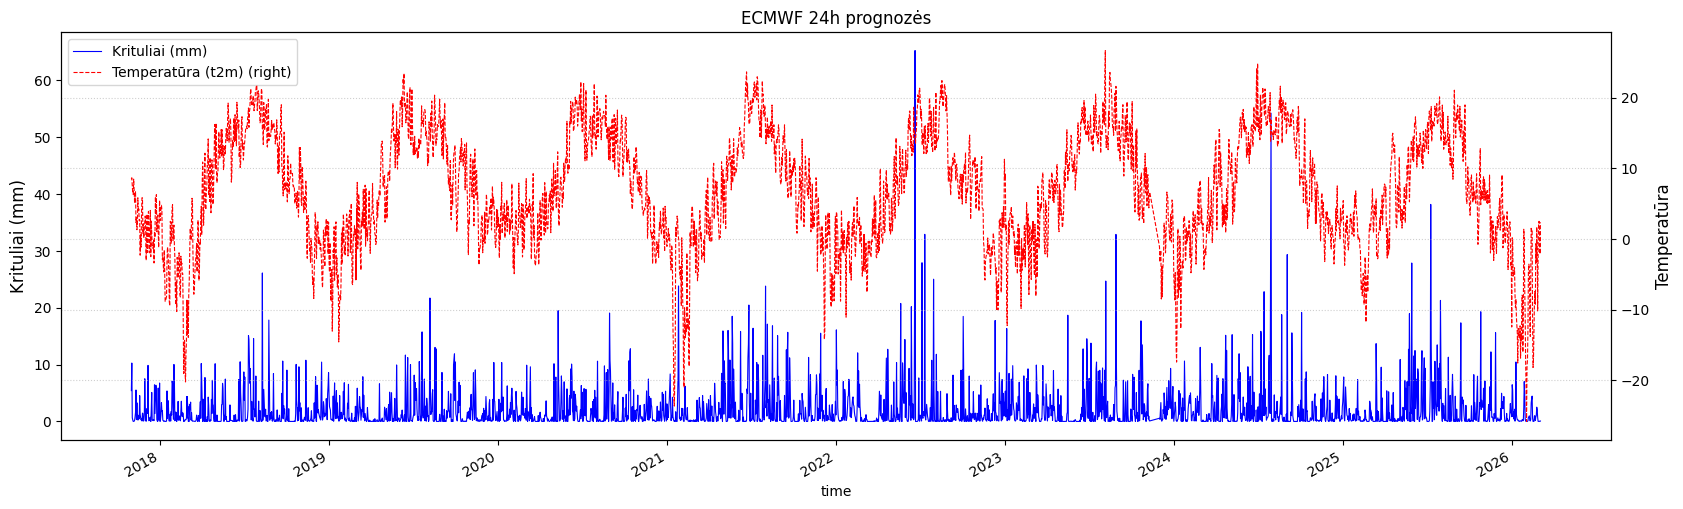

In [41]:
import matplotlib.pyplot as plt

df_time_idx = df.set_index('time')

ax = df_time_idx.tp.plot(figsize=(20, 6), linewidth=0.8, color='blue', label='Krituliai (mm)')
df_time_idx.t2m.plot(ax=ax, secondary_y=True, linewidth=0.8, linestyle='--', color='red', label='Temperatūra (t2m)')

ax.set_ylabel('Krituliai (mm)', fontsize=12)
ax.right_ax.set_ylabel('Temperatūra', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("ECMWF 24h prognozės")

plt.show()

In [43]:
df.to_csv(f"Vilnius_ecmwf_data_2017_2026.csv", index=False)